In [201]:
import numpy as np
import matplotlib.pyplot as plt     

In [202]:
%%bash
cd ..
g++ -std=c++17 -Wall Curve.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o Curvilinear

        

ERROR! Session/line number was not unique in database. History logging moved to new session 5873


SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:575:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  575 |         bool ghost_flag = false;
      |              ^~~~~~~~~~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:119:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  119 |     double gamma = 1.4;
      |            ^~~~~


In [203]:
%%bash
cd ..
./Curvilinear

Shape = (1024, 4)
setting pointersMMS boundary inflowSetting ambient Conditions...  Density   : 0.224719  U-velocity: 167.643  V-velocity: 173.597  Pressure  : 215264
  Density   : 0.224  U-velocity: 167.448  V-velocity: 173.41  Pressure  : 215119
  Density   : 0.223286  U-velocity: 167.254  V-velocity: 173.222  Pressure  : 214972
  Density   : 0.222577  U-velocity: 167.058  V-velocity: 173.034  Pressure  : 214824
  Density   : 0.221873  U-velocity: 166.863  V-velocity: 172.845  Pressure  : 214675
  Density   : 0.221173  U-velocity: 166.666  V-velocity: 172.655  Pressure  : 214526
  Density   : 0.220478  U-velocity: 166.47  V-velocity: 172.464  Pressure  : 214375
  Density   : 0.219787  U-velocity: 166.272  V-velocity: 172.273  Pressure  : 214223
  Density   : 0.219101  U-velocity: 166.075  V-velocity: 172.082  Pressure  : 214070
  Density   : 0.218419  U-velocity: 165.877  V-velocity: 171.89  Pressure  : 213916
  Density   : 0.217741  U-velocity: 165.678  V-velocity: 171.697  Pressure

In [204]:
rho = 0.761065
u   = 34.6842
v   = 34.6842
p   = 65396.9

cell_R = np.array([rho,u,v,p])
cell_L = np.array([.7648,0,0,65855])



In [205]:


data = np.loadtxt("../primitives.csv", delimiter=",")
NI = 32
NJ = 32
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 1024)


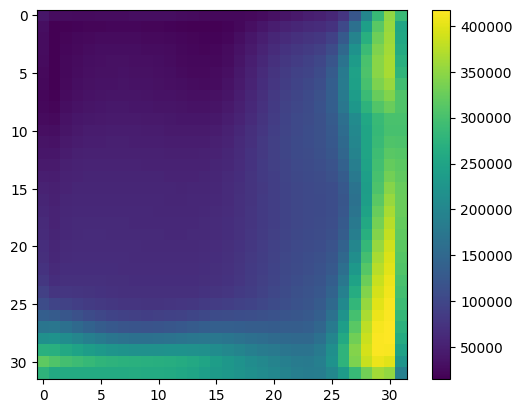

In [206]:
p = p.reshape((32,32))
plt.imshow(p)
plt.colorbar()

In [207]:
def load_grid(filename):

    with open(filename, 'r') as f:
        # Read integers
        nzones = int(f.readline())
        imax, jmax, kmax = map(int, f.readline().split())

        size = imax * jmax * kmax

        # Read the flattened data for x, y, and zztemp
        data = []
        while len(data) < 3 * size:
            line = f.readline()
            data.extend(map(float, line.split()))

        # Split data into x, y, zztemp
        data = np.array(data)
        x = data[0:size].reshape((kmax, jmax, imax))
        y = data[size:2*size].reshape((kmax, jmax, imax))
        zztemp = data[2*size:].reshape((kmax, jmax, imax))

    return x[0],y[0]
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL2/Meshes/curv2d33.grd")

In [208]:
import numpy as np

# Constants
pi = np.pi  # or use 3.14159265358979323846 explicitly if you want exact match

rho0   = 1.0
rhox   = 0.15
rhoy   = -0.1

uvel0  = 800.0
uvelx  = 50.0
uvely  = -30.0

vvel0  = 800.0
vvelx  = -75.0
vvely  = 40.0

press0 = 100000.0
pressx = 20000.0
pressy = 50000.0


In [209]:
def rho_mms(length, x, y):
    return rho0 + rhoy * np.cos((np.pi * y) / (2.0 * length)) + rhox * np.sin((np.pi * x) / length)

def uvel_mms(length, x, y):
    return uvel0 + uvely * np.cos((3.0 * np.pi * y) / (5.0 * length)) + uvelx * np.sin((3.0 * np.pi * x) / (2.0 * length))

def vvel_mms(length, x, y):
    return vvel0 + vvelx * np.cos((np.pi * x) / (2.0 * length)) + vvely * np.sin((2.0 * np.pi * y) / (3.0 * length))

def press_mms(length, x, y):
    return press0 + pressx * np.cos((2.0 * np.pi * x) / length) + pressy * np.sin((np.pi * y) / length)

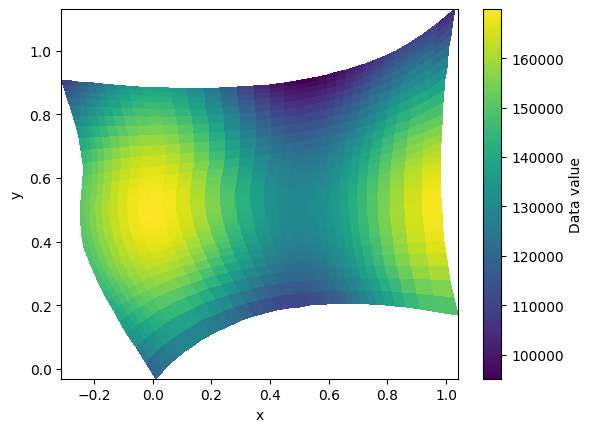

In [210]:

plt.pcolormesh(x[:,:], y[:,:], press_mms(1,x,y), shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

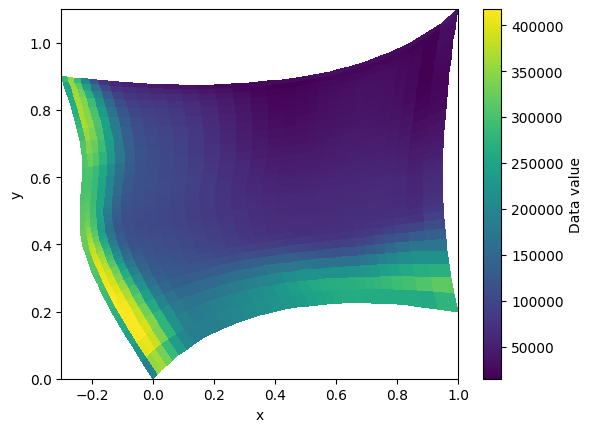

In [211]:
 

plt.pcolormesh(x[:,:], y[:,:], p[:,:], shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

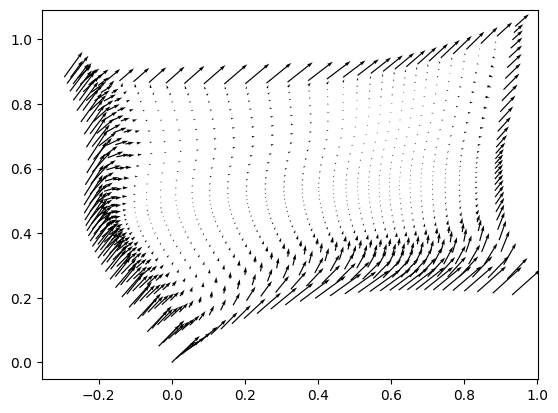

In [212]:
plt.quiver(x[1:,1:],y[1:,1:],u,v)